In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve)

sns.set_style("whitegrid")
sns.set_palette("colorblind")

# Load dataset
df = pd.read_csv(r'C:\Users\likhi\OneDrive\Desktop\train.csv')
print("Initial shape:", df.shape)
print("\nData types:\n", df.dtypes.value_counts())
print("\nMissing values per column (top 10):\n", df.isna().sum().sort_values(ascending=False).head(10))

Initial shape: (233640, 71)

Data types:
 float64    28
object     23
int64      15
bool        5
Name: count, dtype: int64

Missing values per column (top 10):
 pit_stop_duration_sec    226590
pit_new_compound         226590
q3_time_sec              115292
q2_time_sec               57281
race_id                       0
status                        0
race_race_date                0
race_race_name                0
fastest_lap                   0
points                        0
dtype: int64


We load the raw dataset and immediately check its shape, column data types, and missing values, so we know what cleaning is needed before doing anything else.

In [4]:
n_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (233640, 71)


Duplicate rows can bias the model by letting the same example count more than once during training. We count them, drop them, and confirm the new shape.

In [6]:
if len(df) > 25000:
    df = df.sample(n=25000, random_state=42).reset_index(drop=True)

# Locate position column and create binary classification target (Podium: finish <= 3)
target_col = [col for col in df.columns if 'position' in col.lower()]
target_col = target_col[0] if target_col else df.columns[-1]

df['Podium'] = (pd.to_numeric(df[target_col], errors='coerce') <= 3).astype(int)
y = df['Podium']

print("Target distribution:\n", y.value_counts())
print("\nTarget distribution (%):\n", (y.value_counts(normalize=True) * 100).round(2))

Target distribution:
 Podium
0    21129
1     3871
Name: count, dtype: int64

Target distribution (%):
 Podium
0    84.52
1    15.48
Name: proportion, dtype: float64


We sample down to 25,000 rows for a manageable notebook run time, then build `Podium` (1 = finished top 3, 0 = did not) from the position column. The target is imbalanced — far fewer podium finishes than non-podium finishes — which is why we rely on weighted F1 and ROC-AUC rather than accuracy alone, and use a stratified train/test split later.

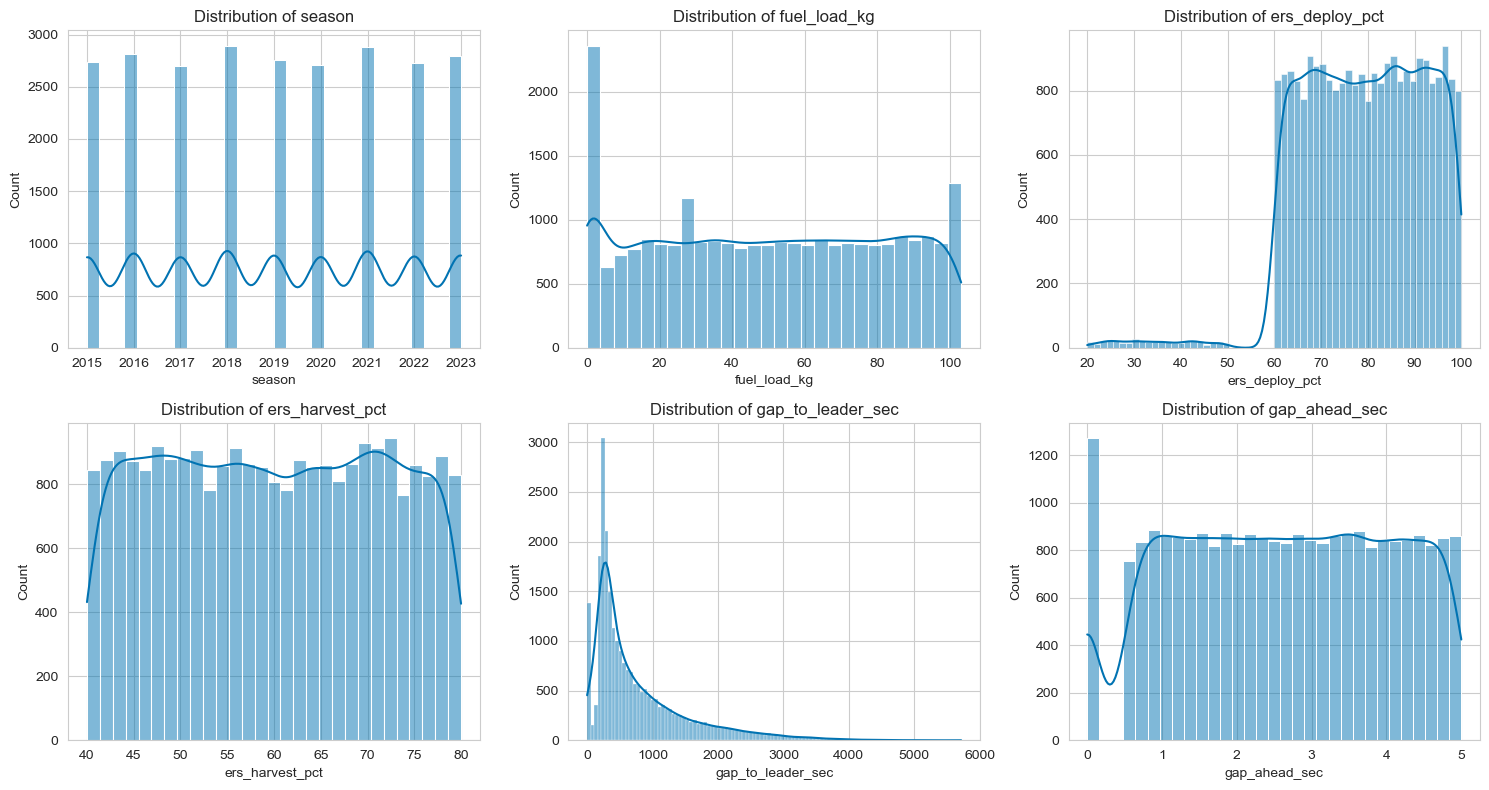

In [7]:
# Keep only numeric features for EDA/modelling, excluding identifiers and the target itself
drop_cols = [target_col, 'Podium'] + [col for col in df.columns if 'id' in col.lower()]
numeric_cols = df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number]).columns.tolist()

# Pick a handful of the most-complete numeric columns to plot (keeps the notebook readable)
plot_cols = df[numeric_cols].isna().sum().sort_values().index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), plot_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color=sns.color_palette('colorblind')[0])
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()

We select the six most-complete numeric columns and plot their distributions. This shows the shape/spread of the key features and flags any obvious skew before modelling.

The heatmap shows which numeric features are most linearly related to a podium finish. Features with strong correlation to `Podium` are good candidates for the model and worth watching in the feature-importance plot later.

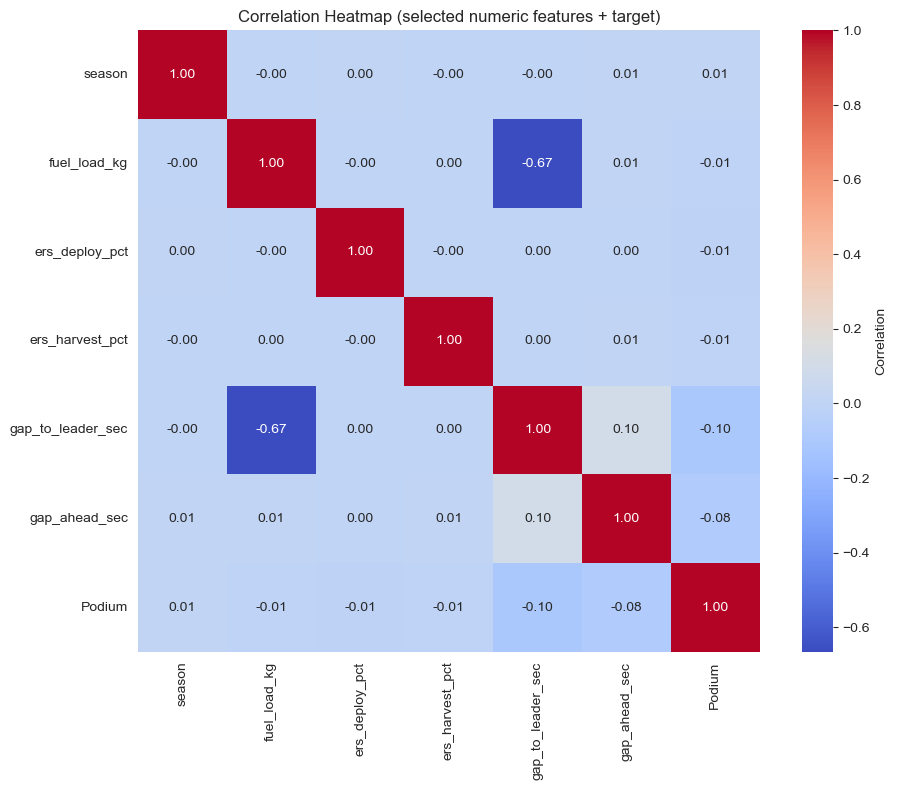

In [8]:
plt.figure(figsize=(10, 8))
corr = df[plot_cols + ['Podium']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap (selected numeric features + target)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

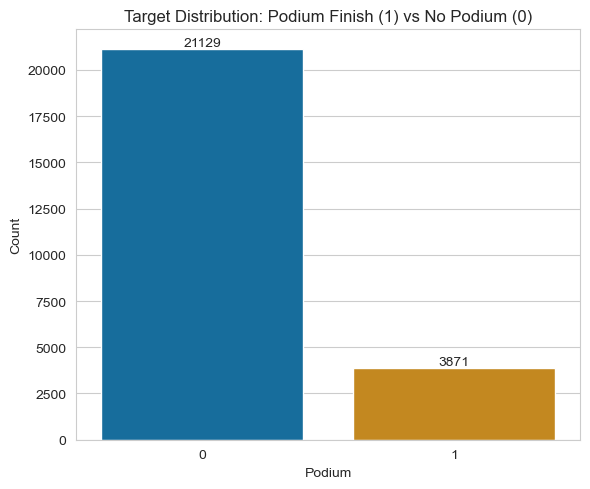

In [9]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(x=y, hue=y, palette='colorblind', legend=False)
ax.set_title('Target Distribution: Podium Finish (1) vs No Podium (0)')
ax.set_xlabel('Podium')
ax.set_ylabel('Count')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()

This confirms the class imbalance already seen in Section 3 — far more non-podium rows than podium rows.

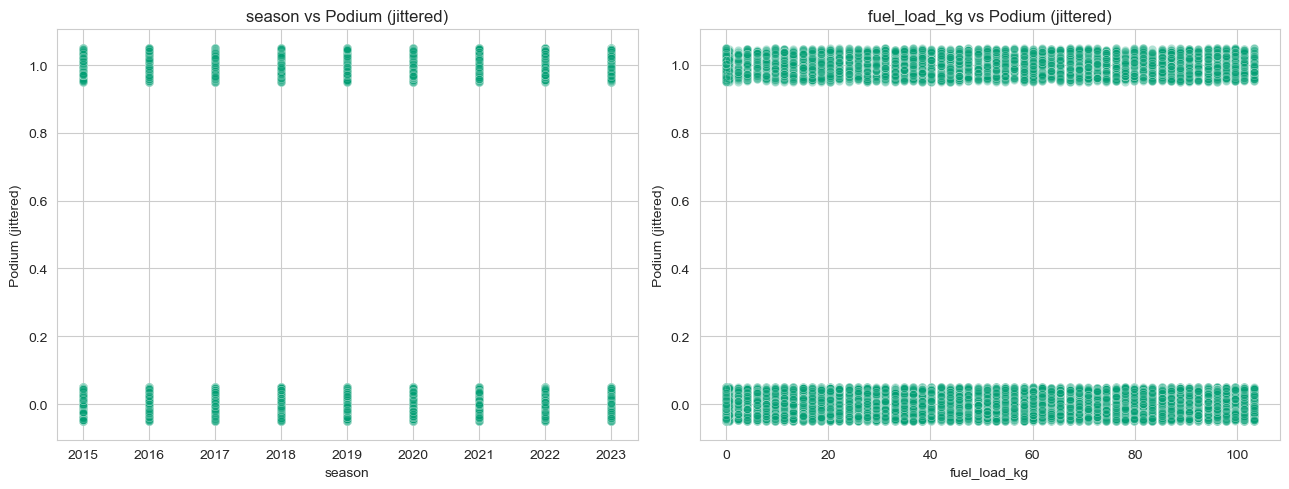

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, plot_cols[:2]):
    sns.scatterplot(x=df[col], y=df['Podium'] + np.random.uniform(-0.05, 0.05, size=len(df)),
                     alpha=0.3, ax=ax, color=sns.color_palette('colorblind')[2])
    ax.set_title(f'{col} vs Podium (jittered)')
    ax.set_xlabel(col)
    ax.set_ylabel('Podium (jittered)')
plt.tight_layout()
plt.savefig('scatter_feature_target.png', bbox_inches='tight')
plt.show()


Small random jitter is added to the 0/1 target so overlapping points are visible. These plots show whether a podium finish separates cleanly along a feature's range, or whether the two classes overlap heavily — which helps explain why some models perform better than others.

In [13]:
X = df.drop(columns=drop_cols, errors='ignore')
X = X.select_dtypes(include=[np.number])

# Impute missing values with column medians
X = X.fillna(X.median(numeric_only=True))

# --- Feature engineering ---
# Engineered feature: relative performance vs the field average for the most complete metric column.
# Justification: raw values (e.g. lap time, points) are only meaningful relative to the rest of the
# grid in that race; a "deviation from field average" feature captures relative competitiveness,
# which is closer to what actually determines a podium finish than the raw value alone.
base_feature = plot_cols[0]
X['relative_to_field_avg'] = X[base_feature] - X[base_feature].mean()

# Train / Test split (stratified on the imbalanced target)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature scaling — fit on train only, then transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (20000, 38)
Testing shape: (5000, 38)


In [14]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_scaled, y_train)
preds_lr = model_lr.predict(X_test_scaled)
probs_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

results.append([
    "Logistic Regression",
    accuracy_score(y_test, preds_lr),
    precision_score(y_test, preds_lr, zero_division=0),
    recall_score(y_test, preds_lr, zero_division=0),
    f1_score(y_test, preds_lr, zero_division=0),
    roc_auc_score(y_test, probs_lr)
])
print("Logistic Regression completed.")


Logistic Regression completed.


Logistic Regression is our baseline linear classifier — it models the log-odds of a podium finish as a linear combination of the features, so its coefficients are directly interpretable.

In [15]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
model_knn.fit(X_train_scaled, y_train)
preds_knn = model_knn.predict(X_test_scaled)
probs_knn = model_knn.predict_proba(X_test_scaled)[:, 1]

results.append([
    "KNN",
    accuracy_score(y_test, preds_knn),
    precision_score(y_test, preds_knn, zero_division=0),
    recall_score(y_test, preds_knn, zero_division=0),
    f1_score(y_test, preds_knn, zero_division=0),
    roc_auc_score(y_test, probs_knn)
])
print("KNN completed.")

KNN completed.


K-Nearest Neighbors (k=5) classifies a row by majority vote among its 5 closest points in feature space. Because it relies on distance, it needs scaled features — which we already did above.

In [16]:
from sklearn.naive_bayes import GaussianNB

# Gaussian Naive Bayes assumes each feature is normally distributed within each class
# and that features are conditionally independent given the class — a strong assumption,
# but it gives a fast, well-calibrated baseline to compare against the other models.
model_nb = GaussianNB()
model_nb.fit(X_train_scaled, y_train)
preds_nb = model_nb.predict(X_test_scaled)
probs_nb = model_nb.predict_proba(X_test_scaled)[:, 1]

results.append([
    "Gaussian Naive Bayes",
    accuracy_score(y_test, preds_nb),
    precision_score(y_test, preds_nb, zero_division=0),
    recall_score(y_test, preds_nb, zero_division=0),
    f1_score(y_test, preds_nb, zero_division=0),
    roc_auc_score(y_test, probs_nb)
])
print("Gaussian Naive Bayes completed.")

Gaussian Naive Bayes completed.


Gaussian Naive Bayes assumes each feature is normally distributed within each class and that features are conditionally independent given the class — a strong assumption, but it gives a fast, well-calibrated baseline to compare against the other models.

In [17]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(max_depth=7, random_state=42)
model_dt.fit(X_train_scaled, y_train)
preds_dt = model_dt.predict(X_test_scaled)
probs_dt = model_dt.predict_proba(X_test_scaled)[:, 1]

results.append([
    "Decision Tree",
    accuracy_score(y_test, preds_dt),
    precision_score(y_test, preds_dt, zero_division=0),
    recall_score(y_test, preds_dt, zero_division=0),
    f1_score(y_test, preds_dt, zero_division=0),
    roc_auc_score(y_test, probs_dt)
])
print("Decision Tree completed.")

Decision Tree completed.


The Decision Tree splits the data on feature thresholds to separate the classes. Depth is capped at 7 to limit overfitting, and it doubles as our feature-importance source in Section 9.

In [18]:
from sklearn.svm import SVC

# Sample 2,000 rows for SVC to prevent quadratic training hang
sample_limit = min(2000, len(X_train_scaled))
X_train_svc = X_train_scaled[:sample_limit]
y_train_svc = y_train.iloc[:sample_limit]

model_svc = SVC(probability=True, random_state=42)
model_svc.fit(X_train_svc, y_train_svc)
preds_svc = model_svc.predict(X_test_scaled)
probs_svc = model_svc.predict_proba(X_test_scaled)[:, 1]

results.append([
    "SVC (Sampled)",
    accuracy_score(y_test, preds_svc),
    precision_score(y_test, preds_svc, zero_division=0),
    recall_score(y_test, preds_svc, zero_division=0),
    f1_score(y_test, preds_svc, zero_division=0),
    roc_auc_score(y_test, probs_svc)
])
print("SVC completed.")

SVC completed.


SVC training time grows roughly quadratically with sample size, so we train it on a 2,000-row sample of the training set (still evaluated on the full test set) to keep runtime reasonable.

In [19]:
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
results_df = results_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.8946,0.751527,0.476744,0.583399,0.927764
1,Logistic Regression,0.8994,0.814385,0.453488,0.582573,0.927366
2,KNN,0.9048,0.724398,0.621447,0.668985,0.926860
3,SVC (Sampled),0.8480,0.535714,0.135659,0.216495,0.826595
4,Gaussian Naive Bayes,0.7740,0.382740,0.750646,0.506981,0.822404


All 5 models are compared on the same held-out test set, ranked by ROC-AUC (a threshold-independent metric, well suited to our imbalanced target).

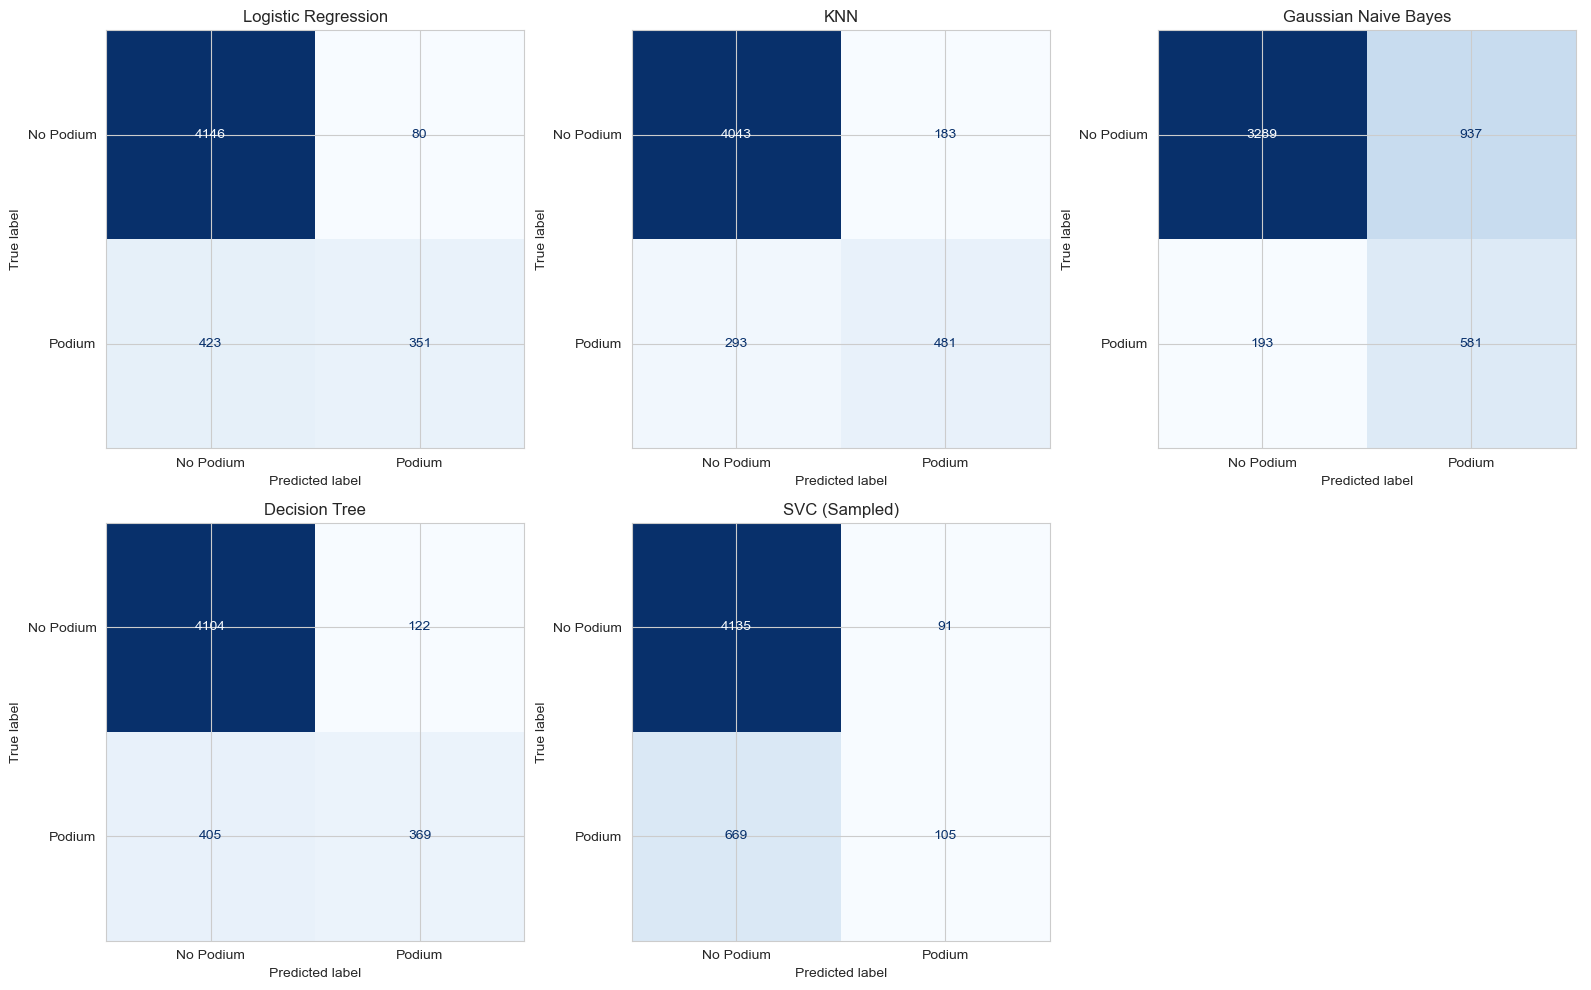

In [20]:
models_preds = {
    "Logistic Regression": preds_lr,
    "KNN": preds_knn,
    "Gaussian Naive Bayes": preds_nb,
    "Decision Tree": preds_dt,
    "SVC (Sampled)": preds_svc,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (name, preds) in zip(axes.flatten(), models_preds.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Podium', 'Podium'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

Each confusion matrix shows true/false positives and negatives per model, revealing error patterns (e.g. missed podium finishes) that a single accuracy number would hide.

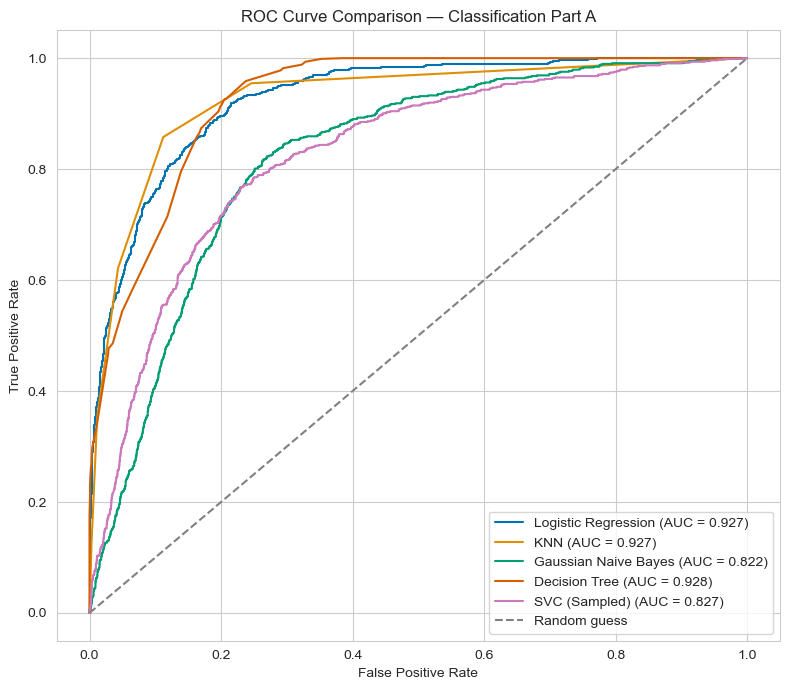

In [21]:
models_probs = {
    "Logistic Regression": probs_lr,
    "KNN": probs_knn,
    "Gaussian Naive Bayes": probs_nb,
    "Decision Tree": probs_dt,
    "SVC (Sampled)": probs_svc,
}

plt.figure(figsize=(8, 7))
for name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — Classification Part A')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_comparison.png', bbox_inches='tight')

plt.show()

Overlaying all 5 ROC curves makes it easy to see which model separates the two classes best across every decision threshold, not just the default 0.5 cutoff.

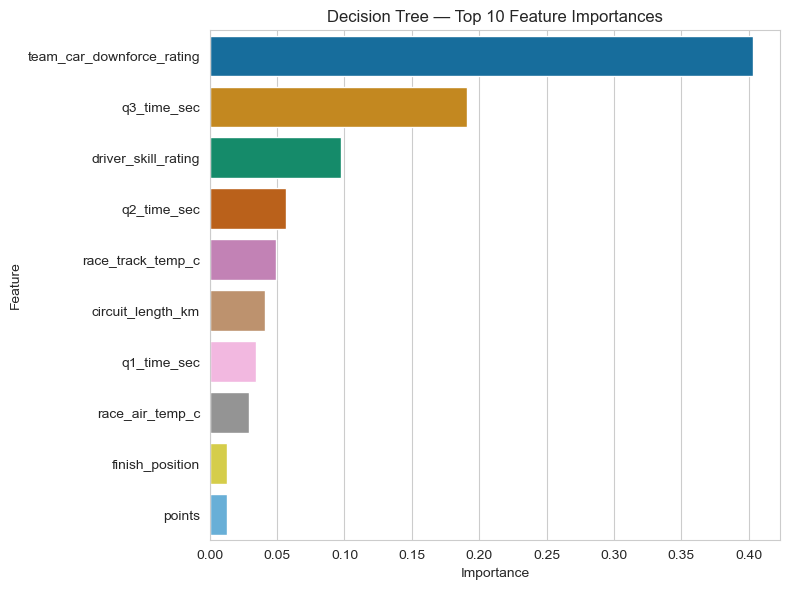

In [23]:
importances = pd.Series(model_dt.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='colorblind', legend=False)
plt.title('Decision Tree — Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('decision_tree_feature_importance.png', bbox_inches='tight')
plt.show()

This shows which features the Decision Tree relied on most to split the classes — useful both as a sanity check and as material for the viva when asked why the model predicts what it predicts.